In [3]:
import pandas as pd
df = pd.read_csv('Subject 1.csv', parse_dates=['EventDateTime'])
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11042 entries, 0 to 11041
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   EventDateTime               11042 non-null  datetime64[ns]
 1   DeviceMode                  0 non-null      float64       
 2   BolusType                   593 non-null    object        
 3   Basal                       7419 non-null   float64       
 4   CorrectionDelivered         593 non-null    float64       
 5   TotalBolusInsulinDelivered  593 non-null    float64       
 6   FoodDelivered               593 non-null    float64       
 7   CarbSize                    593 non-null    float64       
 8   CGM                         11042 non-null  int64         
dtypes: datetime64[ns](1), float64(6), int64(1), object(1)
memory usage: 776.5+ KB


In [4]:
df = df.sort_values('EventDateTime')

In [5]:
df['EventDateTime'] = pd.to_datetime(df['EventDateTime'])
df = df.set_index('EventDateTime')

In [6]:
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['day_night'] = df['hour'].apply(lambda x: 0 if (x < 6 or x >= 20) else 1)


In [7]:
import numpy as np

df['hour_sin'] = np.sin(2 * np.pi * df['hour']/24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour']/24)

df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week']/7)
df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week']/7)



In [8]:
df['FoodDelivered'].fillna(0, inplace=True)
df['TotalBolusInsulinDelivered'].fillna(0,inplace=True)

/var/folders/8r/w2tfcf3d63b2dfp05x4fmyx40000gn/T/ipykernel_45921/2558290490.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['FoodDelivered'].fillna(0, inplace=True)
/var/folders/8r/w2tfcf3d63b2dfp05x4fmyx40000gn/T/ipykernel_45921/2558290490.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always be

In [9]:
df = df.drop(columns=['DeviceMode'])

In [10]:
df['BolusType'] = df['BolusType'].fillna('NoBolus')

In [11]:
df = pd.get_dummies(df, columns=['BolusType'], prefix='Bolus')

In [12]:
df['ActiveBolus'] = df['TotalBolusInsulinDelivered'].rolling(window=24, min_periods=1).sum()

In [13]:
df['FoodDelivered'].fillna(0, inplace=True)
df['CarbSize'].fillna(0, inplace=True)
df['TotalBolusInsulinDelivered'].fillna(0, inplace=True)
df['Basal'].fillna(method='ffill', inplace=True)  
df['CorrectionDelivered'].fillna(0, inplace=True) 
df['Basal'].fillna(df['Basal'].mean(), inplace=True)


/var/folders/8r/w2tfcf3d63b2dfp05x4fmyx40000gn/T/ipykernel_45921/1495881271.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['FoodDelivered'].fillna(0, inplace=True)
/var/folders/8r/w2tfcf3d63b2dfp05x4fmyx40000gn/T/ipykernel_45921/1495881271.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always be

In [14]:
features = [
    'hour_sin', 'hour_cos',
    'day_of_week_sin', 'day_of_week_cos',
    'day_night',
    'FoodDelivered', 'CarbSize',
    'TotalBolusInsulinDelivered', 'Basal', 'CorrectionDelivered',
    'ActiveBolus', 'Bolus_Automatic Bolus/Correction', 'Bolus_BLE Standard Bolus/Correction', 'Bolus_Extended 50.00%/0.00',
    'Bolus_Standard', 'Bolus_Standard/Correction', 'Bolus_NoBolus'
]

target = 'CGM'

In [15]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df[features] = scaler.fit_transform(df[features])

import numpy as np

X, y = [], []
window_size = 12  
for i in range(len(df) - window_size):
    X.append(df[features].iloc[i:i+window_size].values)
    y.append(df[target].iloc[i+window_size])  

X = np.array(X)
y = np.array(y)

print(X.shape)  
print(y.shape)  

(11030, 12, 17)
(11030,)


In [16]:
import tensorflow as tf
print(tf.__version__)

2.16.2


Epoch 1/60


/Users/user/anaconda3/envs/my_cozy_env/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


276/276 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0255 - val_loss: 0.0108
Epoch 2/60
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0118 - val_loss: 0.0076
Epoch 3/60
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0091 - val_loss: 0.0067
Epoch 4/60
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0072 - val_loss: 0.0060
Epoch 5/60
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0057 - val_loss: 0.0056
Epoch 6/60
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0050 - val_loss: 0.0059
Epoch 7/60
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0045 - val_loss: 0.0055
Epoch 8/60
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0041 - val_loss: 0.0046
Epoch 9/60
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0040 - val_loss: 0.0054
Epoch 10/60
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0039 - val_loss: 0.0060
Epoch 11/60
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0036 - val_loss: 0.0053
Epoch 12/60
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 24)             │         3,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,349 (40.43 KB)

 Trainable params: 3,449 (13.47 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,900 (26.96 KB)

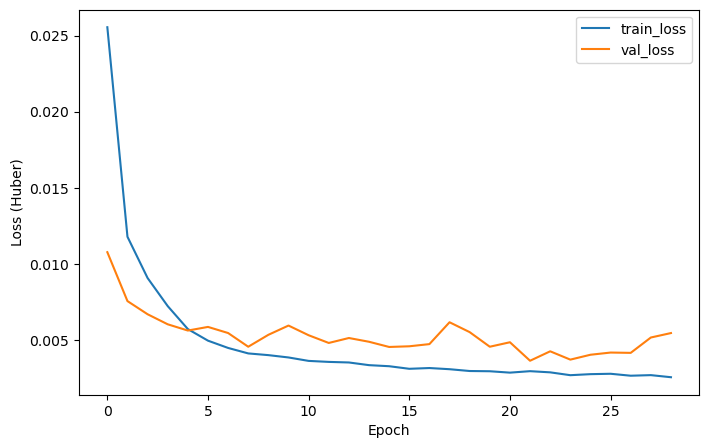

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


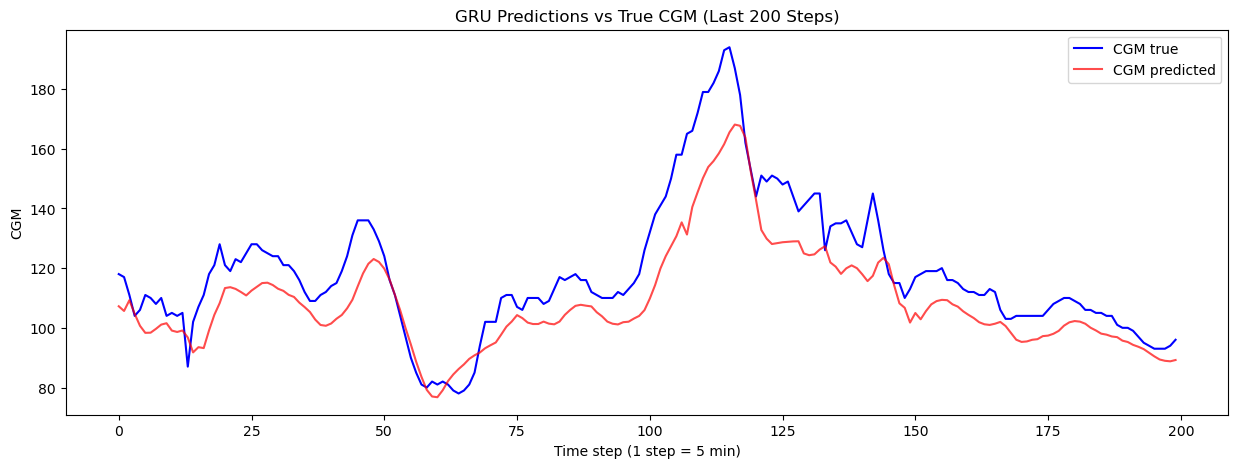

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df['delta_CGM'] = df['CGM'].diff().fillna(0)  
df['CGM_roll_3'] = df['CGM'].rolling(window=3, min_periods=1).mean()  

features_with_delta = features + ['delta_CGM', 'CGM_roll_3']
target = 'CGM'

scaler_X = MinMaxScaler()
df[features_with_delta] = scaler_X.fit_transform(df[features_with_delta])

scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(df[target].values.reshape(-1,1))

window_size = 12  
X, y = [], []

for i in range(len(df) - window_size):
    X.append(df[features_with_delta].iloc[i:i+window_size].values)
    y.append(y_scaled[i+window_size]) 

X = np.array(X)
y = np.array(y)

split = int(len(X) * 0.8)
X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]

model = Sequential()
model.add(GRU(
    24,
    input_shape=(X.shape[1], X.shape[2]),
    dropout=0.2,
    recurrent_dropout=0.1,
    kernel_regularizer=l2(0.0005)
))
model.add(Dense(8, activation='relu'))
model.add(Dense(1))

optimizer = Adam(learning_rate=0.0005)
model.compile(optimizer=optimizer, loss=Huber(delta=1.0))  

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=32,
    callbacks=[early_stop]
)

model.summary()

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (Huber)')
plt.legend()
plt.show()

y_pred_scaled = model.predict(X_val)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_val)

n_steps = 200
plt.figure(figsize=(15,5))
plt.plot(y_true[-n_steps:], label='CGM true', color='blue')
plt.plot(y_pred[-n_steps:], label='CGM predicted', color='red', alpha=0.7)
plt.xlabel('Time step (1 step = 5 min)')
plt.ylabel('CGM')
plt.title('GRU Predictions vs True CGM (Last 200 Steps)')
plt.legend()
plt.show()


In [20]:
errors = np.abs(y_true - y_pred).flatten()
percent_error = errors / y_true.flatten() * 100

df_errors = pd.DataFrame({
    'time_step': np.arange(len(errors)),
    'CGM_true': y_true.flatten(),
    'CGM_pred': y_pred.flatten(),
    'abs_error': errors,
    'percent_error': percent_error
})

top_errors = df_errors.sort_values(by='abs_error', ascending=False).head(10)
print(top_errors)


      time_step  CGM_true    CGM_pred  abs_error  percent_error
273         273     214.0  127.466385  86.533615      40.436269
1165       1165     279.0  205.842606  73.157394      26.221288
274         274     214.0  149.212296  64.787704      30.274628
1164       1164     261.0  200.010574  60.989426      23.367596
1166       1166     270.0  216.570938  53.429062      19.788541
1159       1159     234.0  182.048965  51.951035      22.201297
275         275     214.0  162.499771  51.500229      24.065528
1158       1158     223.0  174.884415  48.115585      21.576496
1160       1160     239.0  191.615891  47.384109      19.825987
578         578     215.0  170.250229  44.749771      20.813847


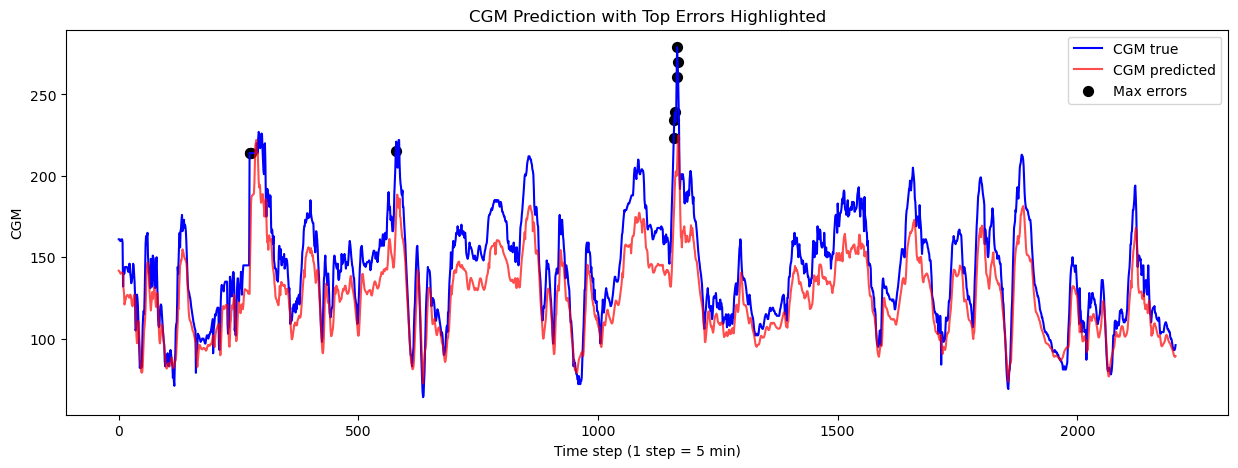

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(y_true, label='CGM true', color='blue')
plt.plot(y_pred, label='CGM predicted', color='red', alpha=0.7)
plt.scatter(top_errors['time_step'], top_errors['CGM_true'], color='black', label='Max errors', s=50)
plt.xlabel('Time step (1 step = 5 min)')
plt.ylabel('CGM')
plt.title('CGM Prediction with Top Errors Highlighted')
plt.legend()
plt.show()
